Info    : Reading './files/1D_mesh.msh'...
Info    : 3 entities
Info    : 101 nodes
Info    : 101 elements
Info    : Done reading './files/1D_mesh.msh'


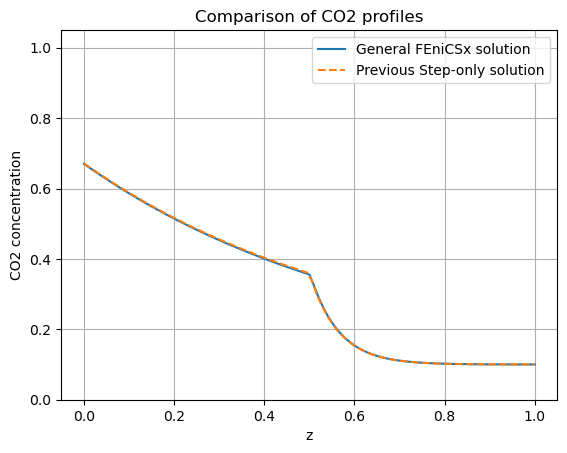

In [8]:
import steady_solver as ss
import matplotlib.pyplot as plt 
import sys 
sys.path.append("../../modules/")
import leaf_model as lm

def compare_solution(z1, c1, z2, c2):
    plt.plot(z1, c1, label="General FEniCSx solution")
    plt.plot(z2, c2, label="Previous Step-only solution", linestyle='dashed')
    plt.xlabel("z")
    plt.ylabel("CO2 concentration")
    plt.title("Comparison of CO2 profiles")
    plt.legend()
    plt.grid()
    plt.ylim(0, 1.05)
    plt.show()

tau, gamma, chi_ = 5, 5, 0.1
rho = (0.1, 0.1, 0.5)
epsilon = 0.001
filename = "./files/run.bp"

leaf = lm.Leaf(tau, gamma, chi_, rho=rho)
domain, solution = leaf.calculate_steady_state_solution()

delta_ = lambda z: ss.step_down(z, min=leaf.deltas.min(), max=leaf.deltas.max(), offset=1-rho[2], epsilon=epsilon)
kappa_ = lambda z: ss.step_up(z, min=leaf.kappas.min(), max=leaf.kappas.max(), offset=1-rho[2], epsilon=epsilon)
meshcontext = ss.get_meshcontext('./files/1D_mesh.msh')
ss.solver(meshcontext, tau, gamma, chi_, delta=delta_, kappa=kappa_, filename=filename, save=True)
z, c = ss.extract_solution_from_file(filename)

compare_solution(z, c, domain, solution)



Info    : Reading './files/1D_mesh.msh'...
Info    : 3 entities
Info    : 101 nodes
Info    : 101 elements
Info    : Done reading './files/1D_mesh.msh'


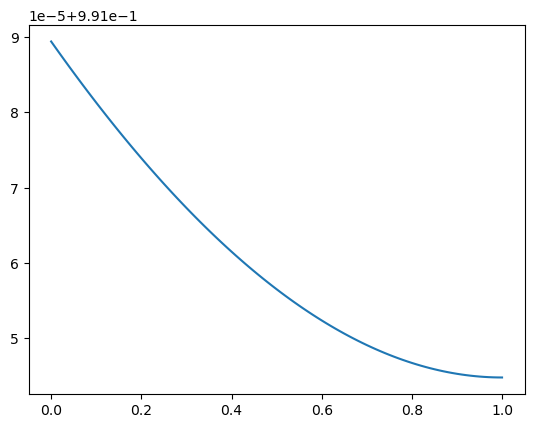

In [2]:
delta = lambda x_: ss.exp_down(x_, 0.1)
kappa = lambda x_: ss.exp_up(x_, 0.1)
meshcontext = ss.get_meshcontext("./files/1D_mesh.msh")
tau, gamma = 0.01, 0.01
mesh, uh = ss.solver(meshcontext, tau, gamma, chi_, delta=delta, kappa=kappa, order=1)
domain, solution = ss.extract_solution_from_objects(mesh, uh, order=1)

plt.plot(domain, solution)